In [139]:
# # Demand Forecasting with CatBoost – Complete EDA & Modeling Notebook
# 
# This notebook builds an end‑to‑end machine learning pipeline to forecast daily demand
# during promotions, using **CatBoost**. 
#
# **Dataset**: `demand_forecasting.csv` (provided)  
# **Goal**: Predict `Demand` (daily units), with special attention to promotional periods.

# ---------------------------------------------------------
# ## 1. Imports & Setup
# ---------------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Modeling
from catboost import CatBoostRegressor, Pool, cv
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import shap

# Plot settings
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100

In [140]:
# ---------------------------------------------------------
# ## 2. Load Data
# ---------------------------------------------------------

# Assumes demand_forecasting.csv is in the working directory
df = pd.read_csv('demand_forecasting.csv', parse_dates=['Date'])
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (76000, 16)


,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59


In [141]:
# ---------------------------------------------------------
# ## 3. Exploratory Data Analysis (EDA)
# ---------------------------------------------------------

# ### 3.1 Basic overview
print("\nColumn types:\n", df.dtypes)
print(f"\nDate range: {df['Date'].min()}  →  {df['Date'].max()}")
print(f"Unique Stores: {df['Store ID'].nunique()}")
print(f"Unique Products: {df['Product ID'].nunique()}")
print(f"Unique Categories: {df['Category'].nunique()}")
print(f"Regions: {df['Region'].unique()}")


Column types:
 Date                  datetime64[ns]
Store ID                      object
Product ID                    object
Category                      object
Region                        object
Inventory Level                int64
Units Sold                     int64
Units Ordered                  int64
Price                        float64
Discount                       int64
Weather Condition             object
Promotion                      int64
Competitor Pricing           float64
Seasonality                   object
Epidemic                       int64
Demand                         int64
dtype: object

Date range: 2022-01-01 00:00:00  →  2024-01-30 00:00:00
Unique Stores: 5
Unique Products: 20
Unique Categories: 5
Regions: ['North' 'South' 'East' 'West']


In [142]:
# ### 3.2 Check for missing values
print("\nMissing values per column:")
print(df.isnull().sum())


Missing values per column:
Date                  0
Store ID              0
Product ID            0
Category              0
Region                0
Inventory Level       0
Units Sold            0
Units Ordered         0
Price                 0
Discount              0
Weather Condition     0
Promotion             0
Competitor Pricing    0
Seasonality           0
Epidemic              0
Demand                0
dtype: int64


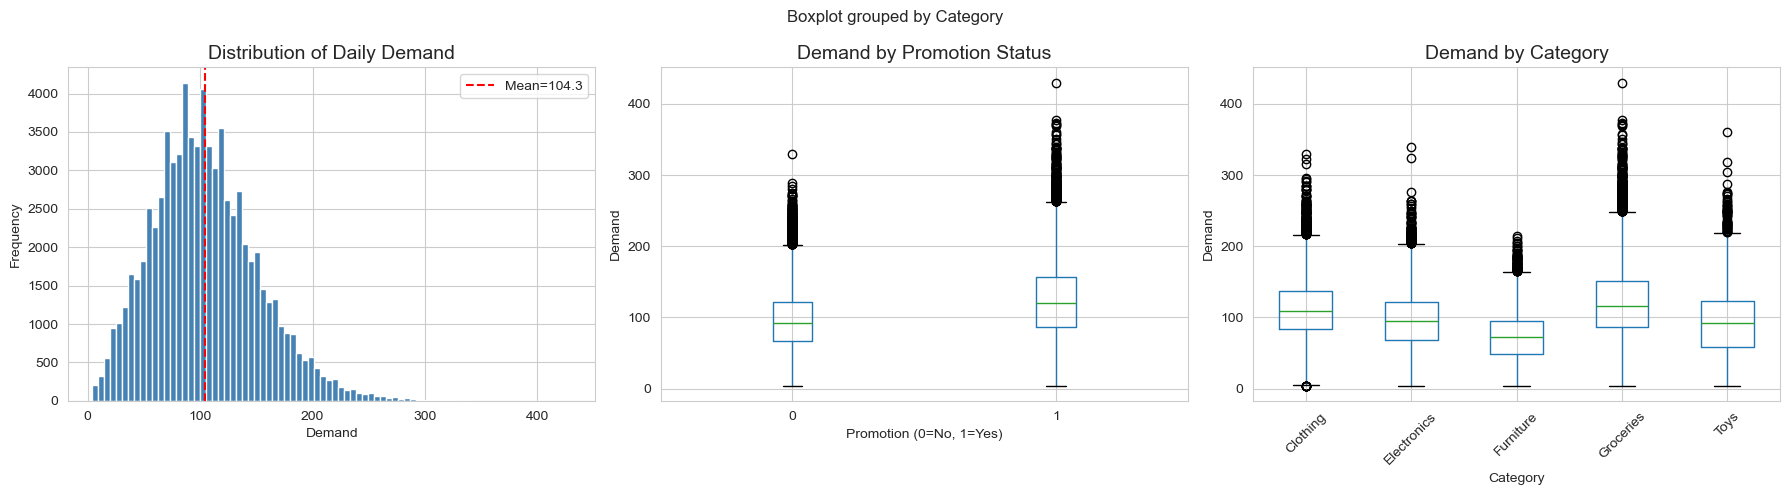

In [143]:
# ### 3.3 Target variable analysis

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Distribution of Demand
axes[0].hist(df['Demand'], bins=80, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Daily Demand', fontsize=14)
axes[0].set_xlabel('Demand')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df['Demand'].mean(), color='red', linestyle='--', label=f'Mean={df["Demand"].mean():.1f}')
axes[0].legend()

# Boxplot by Promotion
df.boxplot(column='Demand', by='Promotion', ax=axes[1])
axes[1].set_title('Demand by Promotion Status', fontsize=14)
axes[1].set_xlabel('Promotion (0=No, 1=Yes)')
axes[1].set_ylabel('Demand')

# Boxplot by Category
df.boxplot(column='Demand', by='Category', ax=axes[2])
axes[2].set_title('Demand by Category', fontsize=14)
axes[2].set_xlabel('Category')
axes[2].set_ylabel('Demand')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

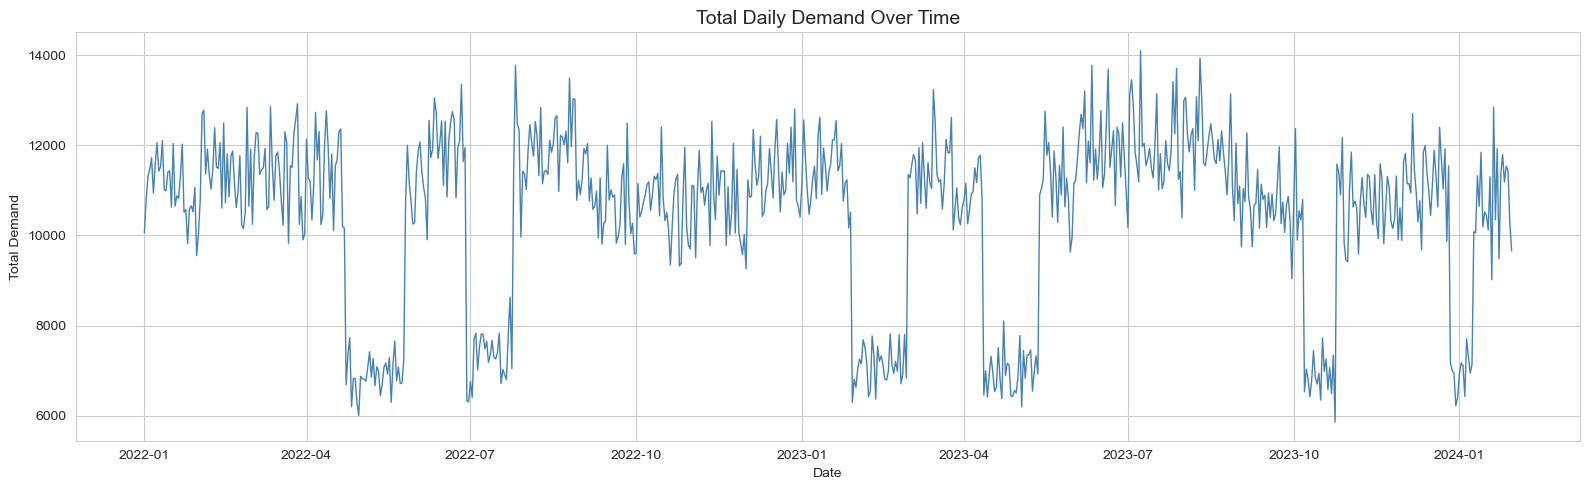

In [147]:
# ### 3.4 Demand over time – daily aggregation

daily_demand = df.groupby('Date')['Demand'].sum().reset_index()

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(daily_demand['Date'], daily_demand['Demand'], color='steelblue', linewidth=1)
ax.set_title('Total Daily Demand Over Time', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Total Demand')
plt.tight_layout()
plt.show()

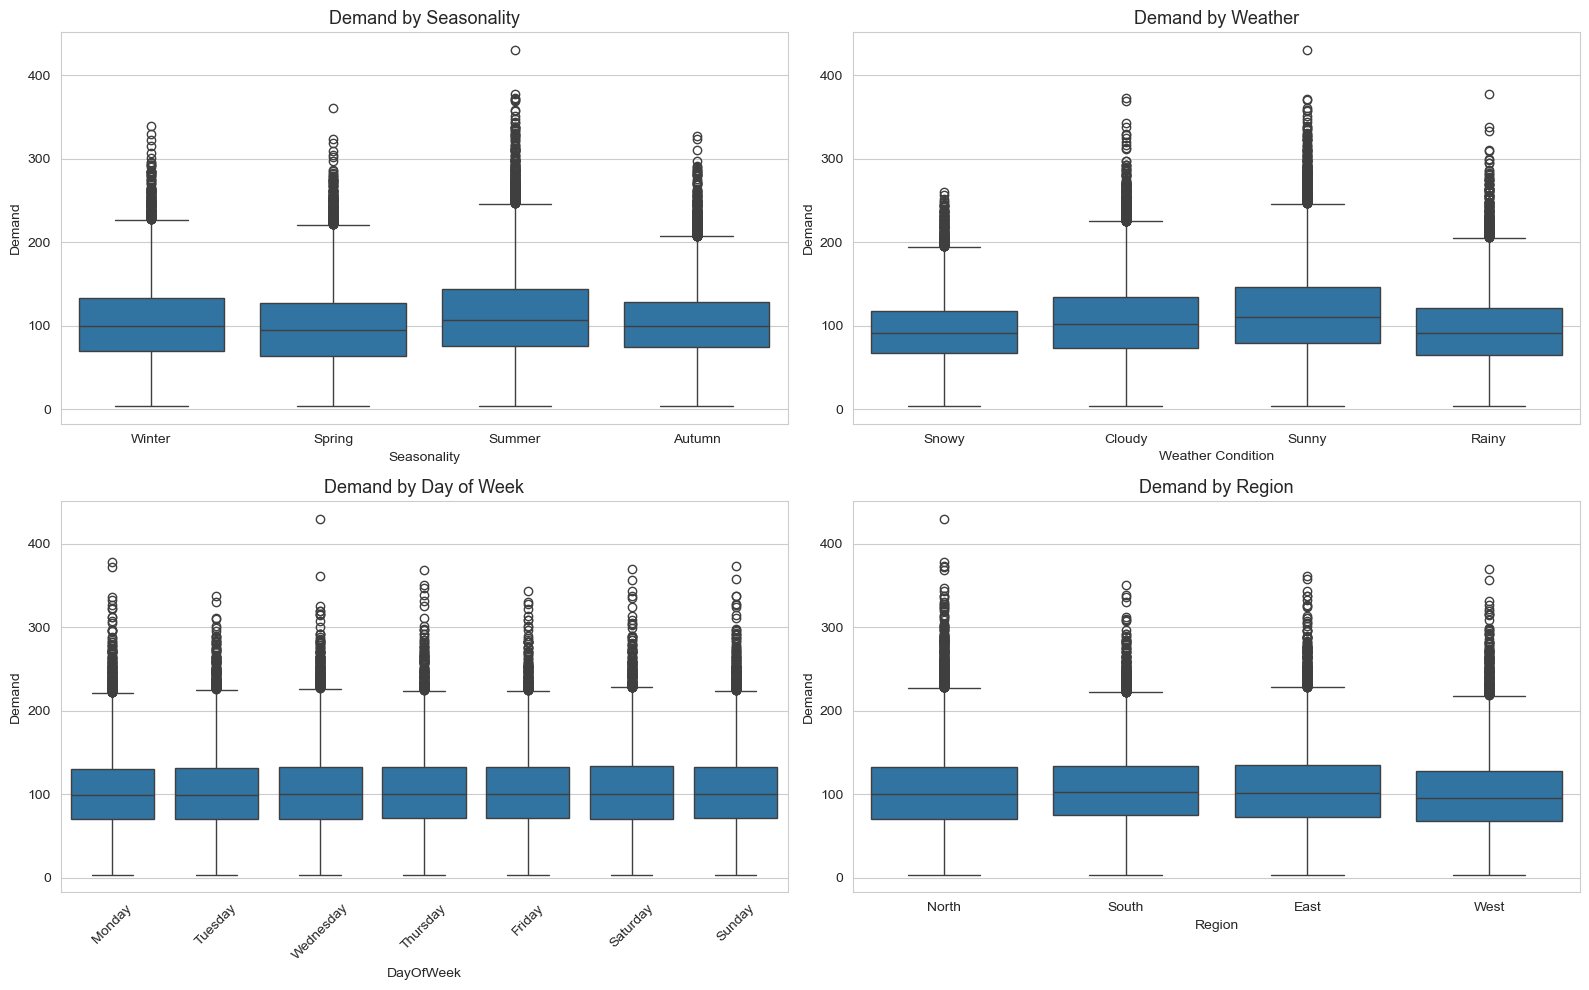

In [149]:
# ### 3.5 Seasonality & Weather effects

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Demand by Seasonality
sns.boxplot(x='Seasonality', y='Demand', data=df, ax=axes[0, 0])
axes[0, 0].set_title('Demand by Seasonality', fontsize=13)

# Demand by Weather Condition
sns.boxplot(x='Weather Condition', y='Demand', data=df, ax=axes[0, 1])
axes[0, 1].set_title('Demand by Weather', fontsize=13)

# Demand by Day of Week
df['DayOfWeek'] = df['Date'].dt.day_name()
order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
sns.boxplot(x='DayOfWeek', y='Demand', data=df, order=order, ax=axes[1, 0])
axes[1, 0].set_title('Demand by Day of Week', fontsize=13)
axes[1, 0].tick_params(axis='x', rotation=45)

# Demand by Region
sns.boxplot(x='Region', y='Demand', data=df, ax=axes[1, 1])
axes[1, 1].set_title('Demand by Region', fontsize=13)

plt.tight_layout()
plt.show()

In [151]:
# ### 3.6 Promotion analysis – how much does promo lift demand?

promo_stats = df.groupby('Promotion')['Demand'].agg(['mean', 'median', 'std', 'count'])
print("Demand statistics by Promotion status:")
print(promo_stats)

lift = (promo_stats.loc[1, 'mean'] - promo_stats.loc[0, 'mean']) / promo_stats.loc[0, 'mean'] * 100
print(f"\nPromotion uplift (mean demand): {lift:.1f}%")

Demand statistics by Promotion status:
                 mean  median        std  count
Promotion                                      
0           95.026843    92.0  40.654269  51000
1          123.269400   120.0  52.900712  25000

Promotion uplift (mean demand): 29.7%


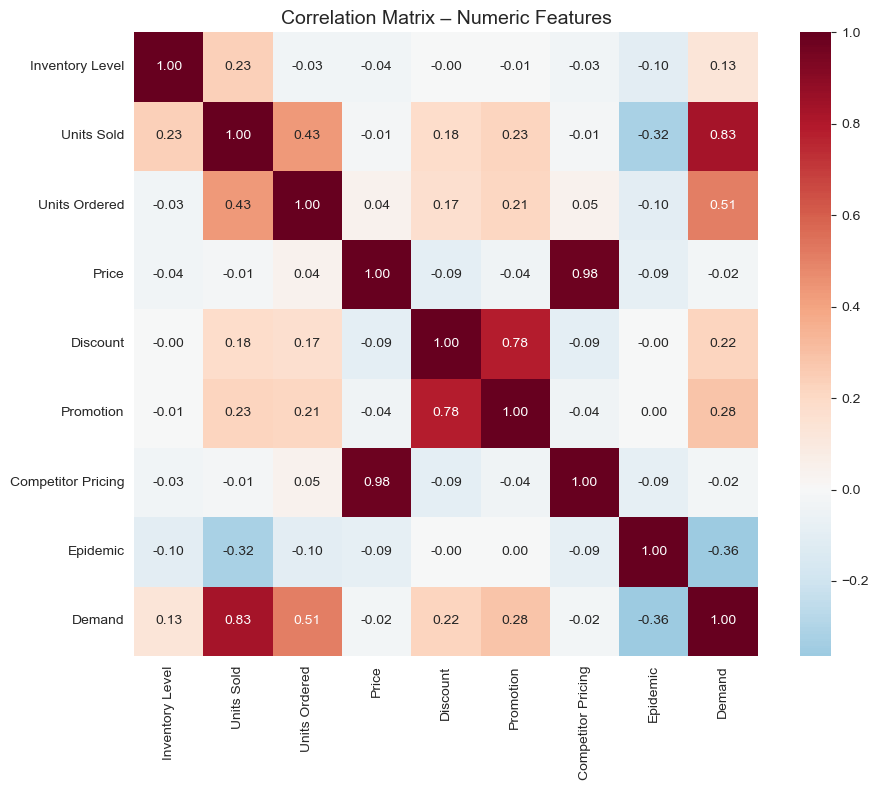

In [152]:
# ### 3.7 Correlation heatmap (numeric columns only)

numeric_cols = df.select_dtypes(include=[np.number]).columns
corr = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, square=True)
plt.title('Correlation Matrix – Numeric Features', fontsize=14)
plt.tight_layout()
plt.show()

In [153]:
# ---------------------------------------------------------
# ## 4. Feature Engineering
# ---------------------------------------------------------

# We'll create lag features and rolling statistics per (Store ID, Product ID)
# because each product-store pair has its own demand dynamics.

def create_features(data):
    """Create time-series features for demand forecasting."""
    df = data.copy()
    df = df.sort_values(['Store ID', 'Product ID', 'Date']).reset_index(drop=True)
    
    # Time-based features
    df['day_of_week'] = df['Date'].dt.dayofweek
    df['month'] = df['Date'].dt.month
    df['day'] = df['Date'].dt.day
    df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)
    df['day_of_year'] = df['Date'].dt.dayofyear
    
    # Price difference (own price vs competitor)
    df['price_diff'] = df['Price'] - df['Competitor Pricing']
    
    # Lag and rolling features – computed per group
    def add_group_features(group):
        group = group.sort_values('Date')
        
        # Lags
        for lag in [1, 2, 3, 7, 14]:
            group[f'demand_lag_{lag}'] = group['Demand'].shift(lag)
        
        # Rolling statistics
        for window in [7, 14, 30]:
            group[f'demand_roll_mean_{window}d'] = group['Demand'].shift(1).rolling(window, min_periods=1).mean()
            group[f'demand_roll_std_{window}d'] = group['Demand'].shift(1).rolling(window, min_periods=1).std()
        
        # Days since last promotion
        group['days_since_last_promo'] = (
            group['Date'] - group['Date'].where(group['Promotion'] == 1).ffill()
        ).dt.days.fillna(999).astype(int)
        
        return group
    
    df = df.groupby(['Store ID', 'Product ID']).apply(add_group_features).reset_index(drop=True)
    
    return df

# Apply feature engineering
df_feat = create_features(df)
print(f"Original shape: {df.shape}, After feature engineering: {df_feat.shape}")
df_feat.head()

Original shape: (76000, 17), After feature engineering: (76000, 35)


,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,...,demand_lag_3,demand_lag_7,demand_lag_14,demand_roll_mean_7d,demand_roll_std_7d,demand_roll_mean_14d,demand_roll_std_14d,demand_roll_mean_30d,demand_roll_std_30d,days_since_last_promo
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,999
1,2022-01-02,S001,P0001,Electronics,North,93,71,0,65.63,5,...,NaN,NaN,NaN,115.000000,NaN,115.000000,NaN,115.000000,NaN,999
2,2022-01-03,S001,P0001,Electronics,North,274,142,229,68.55,15,...,NaN,NaN,NaN,99.500000,21.920310,99.500000,21.920310,99.500000,21.920310,0
3,2022-01-04,S001,P0001,Electronics,North,132,42,0,61.66,10,...,115.0,NaN,NaN,110.333333,24.337899,110.333333,24.337899,110.333333,24.337899,1
4,2022-01-05,S001,P0001,Electronics,North,319,129,0,59.56,25,...,84.0,NaN,NaN,99.500000,29.399546,99.500000,29.399546,99.500000,29.399546,0


In [154]:
# Drop rows with NaN from lag creation (first few days per group)
df_feat = df_feat.dropna(subset=['demand_lag_1', 'demand_lag_7'])
print(f"Shape after dropping NaNs: {df_feat.shape}")

Shape after dropping NaNs: (75300, 35)


In [155]:
# ---------------------------------------------------------
# ## 5. Train / Validation / Test Split (Time‑Based)
# ---------------------------------------------------------

# Sort globally by date
df_feat = df_feat.sort_values('Date').reset_index(drop=True)

# Define split dates
train_end = pd.Timestamp('2022-04-15')
val_end   = pd.Timestamp('2022-04-30')

train = df_feat[df_feat['Date'] <= train_end]
val   = df_feat[(df_feat['Date'] > train_end) & (df_feat['Date'] <= val_end)]
test  = df_feat[df_feat['Date'] > val_end]

print(f"Train: {train.shape}  ({train['Date'].min().date()} → {train['Date'].max().date()})")
print(f"Val:   {val.shape}    ({val['Date'].min().date()} → {val['Date'].max().date()})")
print(f"Test:  {test.shape}   ({test['Date'].min().date()} → {test['Date'].max().date()})")

Train: (9800, 35)  (2022-01-08 → 2022-04-15)
Val:   (1500, 35)    (2022-04-16 → 2022-04-30)
Test:  (64000, 35)   (2022-05-01 → 2024-01-30)


In [156]:
# ---------------------------------------------------------
# ## 5. Train / Validation / Test Split (Time‑Based)
# ---------------------------------------------------------

# Sort globally by date
df_feat = df_feat.sort_values('Date').reset_index(drop=True)

# 重新定义划分日期
train_end = pd.Timestamp('2023-12-15')
val_end   = pd.Timestamp('2024-01-15')

train = df_feat[df_feat['Date'] <= train_end]
val   = df_feat[(df_feat['Date'] > train_end) & (df_feat['Date'] <= val_end)]
test  = df_feat[df_feat['Date'] > val_end]

print(f"Train: {train.shape}  ({train['Date'].min().date()} → {train['Date'].max().date()})")
print(f"Val:   {val.shape}    ({val['Date'].min().date()} → {val['Date'].max().date()})")
print(f"Test:  {test.shape}   ({test['Date'].min().date()} → {test['Date'].max().date()})")

Train: (70700, 35)  (2022-01-08 → 2023-12-15)
Val:   (3100, 35)    (2023-12-16 → 2024-01-15)
Test:  (1500, 35)   (2024-01-16 → 2024-01-30)


In [157]:
# ---------------------------------------------------------
# ## 6. Define Features & Prepare Data
# ---------------------------------------------------------
"""
# Target
target = 'Demand'

# Feature groups
numeric_features = [
    'Inventory Level', 'Units Sold', 'Units Ordered', 'Price', 'Discount',
    'Competitor Pricing', 'Epidemic',
    'day_of_week', 'month', 'day', 'is_weekend', 'day_of_year',
    'price_diff',
    'demand_lag_1', 'demand_lag_2', 'demand_lag_3', 'demand_lag_7', 'demand_lag_14',
    'demand_roll_mean_7d', 'demand_roll_std_7d',
    'demand_roll_mean_14d', 'demand_roll_std_14d',
    'demand_roll_mean_30d', 'demand_roll_std_30d',
    'days_since_last_promo'
]

categorical_features = [
    'Store ID', 'Product ID', 'Category', 'Region',
    'Weather Condition', 'Promotion', 'Seasonality'
]

all_features = numeric_features + categorical_features

# Extract X and y
X_train, y_train = train[all_features], train[target]
X_val,   y_val   = val[all_features],   val[target]
X_test,  y_test  = test[all_features],  test[target]
"""

"\n# Target\ntarget = 'Demand'\n\n# Feature groups\nnumeric_features = [\n    'Inventory Level', 'Units Sold', 'Units Ordered', 'Price', 'Discount',\n    'Competitor Pricing', 'Epidemic',\n    'day_of_week', 'month', 'day', 'is_weekend', 'day_of_year',\n    'price_diff',\n    'demand_lag_1', 'demand_lag_2', 'demand_lag_3', 'demand_lag_7', 'demand_lag_14',\n    'demand_roll_mean_7d', 'demand_roll_std_7d',\n    'demand_roll_mean_14d', 'demand_roll_std_14d',\n    'demand_roll_mean_30d', 'demand_roll_std_30d',\n    'days_since_last_promo'\n]\n\ncategorical_features = [\n    'Store ID', 'Product ID', 'Category', 'Region',\n    'Weather Condition', 'Promotion', 'Seasonality'\n]\n\nall_features = numeric_features + categorical_features\n\n# Extract X and y\nX_train, y_train = train[all_features], train[target]\nX_val,   y_val   = val[all_features],   val[target]\nX_test,  y_test  = test[all_features],  test[target]\n"

In [158]:
# ---------------------------------------------------------
# ## 6. Define Features & Prepare Data
# ---------------------------------------------------------
"""
# Target
target = 'Demand'

# Feature groups
numeric_features = [
    'Inventory Level', 'Price', 'Discount',
    'Competitor Pricing', 'Epidemic',
    'day_of_week', 'month', 'day', 'is_weekend', 'day_of_year',
    'price_diff',
    'demand_lag_1', 'demand_lag_2', 'demand_lag_3', 'demand_lag_7', 'demand_lag_14',
    'demand_roll_mean_7d', 'demand_roll_std_7d',
    'demand_roll_mean_14d', 'demand_roll_std_14d',
    'demand_roll_mean_30d', 'demand_roll_std_30d',
    'days_since_last_promo'
]

categorical_features = [
    'Store ID', 'Product ID', 'Category', 'Region',
    'Weather Condition', 'Promotion', 'Seasonality'
]

all_features = numeric_features + categorical_features

# Extract X and y
X_train, y_train = train[all_features], train[target]
X_val,   y_val   = val[all_features],   val[target]
X_test,  y_test  = test[all_features],  test[target]
"""

"\n# Target\ntarget = 'Demand'\n\n# Feature groups\nnumeric_features = [\n    'Inventory Level', 'Price', 'Discount',\n    'Competitor Pricing', 'Epidemic',\n    'day_of_week', 'month', 'day', 'is_weekend', 'day_of_year',\n    'price_diff',\n    'demand_lag_1', 'demand_lag_2', 'demand_lag_3', 'demand_lag_7', 'demand_lag_14',\n    'demand_roll_mean_7d', 'demand_roll_std_7d',\n    'demand_roll_mean_14d', 'demand_roll_std_14d',\n    'demand_roll_mean_30d', 'demand_roll_std_30d',\n    'days_since_last_promo'\n]\n\ncategorical_features = [\n    'Store ID', 'Product ID', 'Category', 'Region',\n    'Weather Condition', 'Promotion', 'Seasonality'\n]\n\nall_features = numeric_features + categorical_features\n\n# Extract X and y\nX_train, y_train = train[all_features], train[target]\nX_val,   y_val   = val[all_features],   val[target]\nX_test,  y_test  = test[all_features],  test[target]\n"

In [159]:
# ---------------------------------------------------------
# ## 6. Define Features & Prepare Data
# ---------------------------------------------------------

# Target
target = 'Demand'

# Feature groups
numeric_features = [
    'Inventory Level', 'Price', 'Discount',
    'Competitor Pricing', 'Epidemic',
    'day_of_week', 'month', 'day', 'is_weekend', 'day_of_year',
    'price_diff'
]

categorical_features = [
    'Store ID', 'Product ID', 'Category', 'Region',
    'Weather Condition', 'Promotion', 'Seasonality'
]

all_features = numeric_features + categorical_features

# Extract X and y
X_train, y_train = train[all_features], train[target]
X_val,   y_val   = val[all_features],   val[target]
X_test,  y_test  = test[all_features],  test[target]

In [160]:
# ---------------------------------------------------------
# ## 7. Train CatBoost Model
# ---------------------------------------------------------

# Identify categorical column indices for CatBoost
cat_indices = [all_features.index(col) for col in categorical_features]

model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=7,
    l2_leaf_reg=3,
    random_strength=1,
    bagging_temperature=0.5,
    loss_function='RMSE',
    eval_metric='MAE',
    random_seed=42,
    verbose=200,
    early_stopping_rounds=50,
    task_type='CPU'
)

# Train with validation set for early stopping
model.fit(
    X_train, y_train,
    cat_features=cat_indices,
    eval_set=(X_val, y_val),
    plot=False
)

0:	learn: 36.1826286	test: 38.6721154	best: 38.6721154 (0)	total: 15.6ms	remaining: 15.6s
200:	learn: 18.1414508	test: 16.8645779	best: 16.8645779 (200)	total: 3.18s	remaining: 12.6s
400:	learn: 13.0499098	test: 12.3414481	best: 12.3414481 (400)	total: 6.53s	remaining: 9.75s
600:	learn: 9.3962621	test: 9.0833666	best: 9.0833666 (600)	total: 9.75s	remaining: 6.47s
800:	learn: 7.1153319	test: 6.9929294	best: 6.9929294 (800)	total: 13s	remaining: 3.22s
999:	learn: 5.5306547	test: 5.5348961	best: 5.5348961 (999)	total: 16.2s	remaining: 0us

bestTest = 5.534896086
bestIteration = 999



In [161]:
# ---------------------------------------------------------
# ## 8. Model Evaluation
# ---------------------------------------------------------

# Predictions
y_pred_train = model.predict(X_train)
y_pred_val   = model.predict(X_val)
y_pred_test  = model.predict(X_test)

def print_metrics(y_true, y_pred, dataset_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    print(f"\n{dataset_name}:")
    print(f"  MAE : {mae:.2f}")
    print(f"  RMSE: {rmse:.2f}")
    print(f"  MAPE: {mape:.1f}%")
    return mae, rmse, mape

print_metrics(y_train, y_pred_train, "Train")
print_metrics(y_val,   y_pred_val,   "Validation")
print_metrics(y_test,  y_pred_test,  "Test")


Train:
  MAE : 5.42
  RMSE: 7.87
  MAPE: 7.1%

Validation:
  MAE : 5.53
  RMSE: 7.89
  MAPE: 9.8%

Test:
  MAE : 5.16
  RMSE: 7.35
  MAPE: 6.1%


(5.163690714021638, 7.349543521531319, 6.052034091031646)

In [162]:
# ### 8.1 Promo‑period performance (key metric for your resume)

def promo_metrics(y_true, y_pred, X_set, set_name):
    """Evaluate metrics only on promotional days."""
    mask = X_set['Promotion'] == 1
    if mask.sum() == 0:
        print(f"\n{set_name} – No promotional days in this set.")
        return
    y_true_promo = y_true[mask]
    y_pred_promo = y_pred[mask]
    mae  = mean_absolute_error(y_true_promo, y_pred_promo)
    rmse = np.sqrt(mean_squared_error(y_true_promo, y_pred_promo))
    mape = mean_absolute_percentage_error(y_true_promo, y_pred_promo) * 100
    print(f"\n{set_name} – Promotional Periods Only ({mask.sum()} rows):")
    print(f"  MAE : {mae:.2f}")
    print(f"  RMSE: {rmse:.2f}")
    print(f"  MAPE: {mape:.1f}%")

promo_metrics(y_val,  y_pred_val,  X_val,  "Validation")
promo_metrics(y_test, y_pred_test, X_test, "Test")


Validation – Promotional Periods Only (945 rows):
  MAE : 7.61
  RMSE: 10.61
  MAPE: 12.0%

Test – Promotional Periods Only (505 rows):
  MAE : 6.92
  RMSE: 9.63
  MAPE: 7.3%


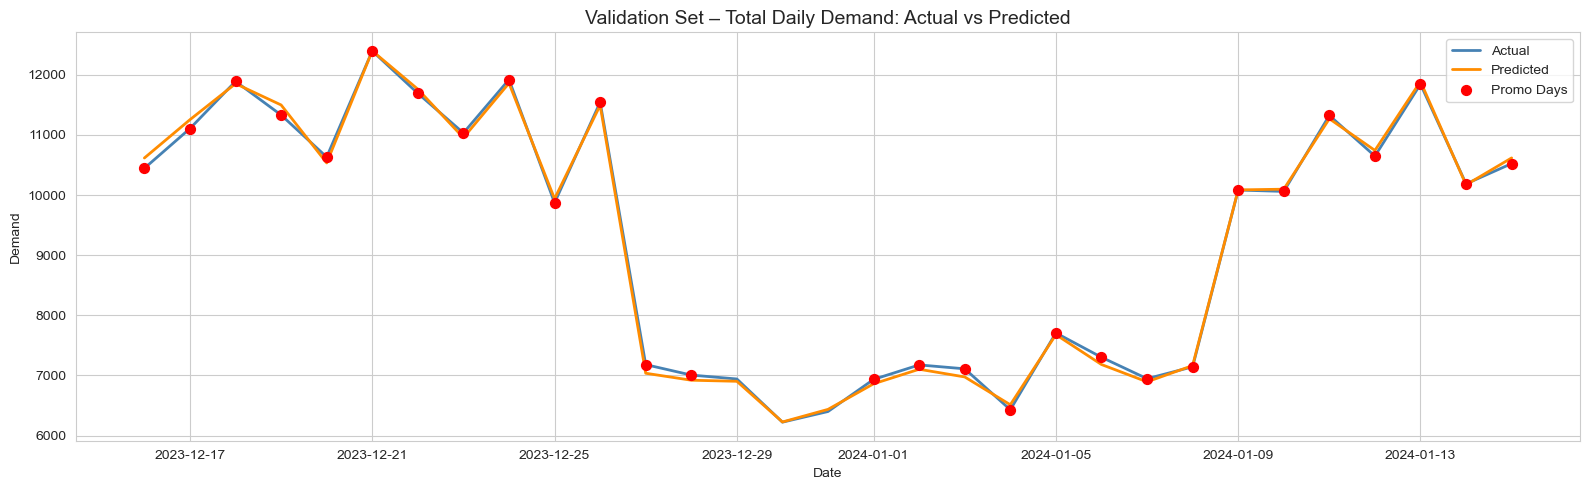

In [163]:
# ---------------------------------------------------------
# ## 9. Actual vs Predicted Plot
# ---------------------------------------------------------

# Aggregate predictions by date for visualisation
val_results = val[['Date', 'Promotion']].copy()
val_results['Actual']  = y_val.values
val_results['Predicted'] = y_pred_val
daily_val = val_results.groupby('Date').agg({'Actual': 'sum', 'Predicted': 'sum'}).reset_index()

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(daily_val['Date'], daily_val['Actual'], label='Actual', color='steelblue', linewidth=2)
ax.plot(daily_val['Date'], daily_val['Predicted'], label='Predicted', color='darkorange', linewidth=2)
# Highlight promo days
promo_days = daily_val[daily_val['Date'].isin(val[val['Promotion'] == 1]['Date'])]
ax.scatter(promo_days['Date'], promo_days['Actual'], color='red', s=50, zorder=5, label='Promo Days')
ax.set_title('Validation Set – Total Daily Demand: Actual vs Predicted', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Demand')
ax.legend()
plt.tight_layout()
plt.show()

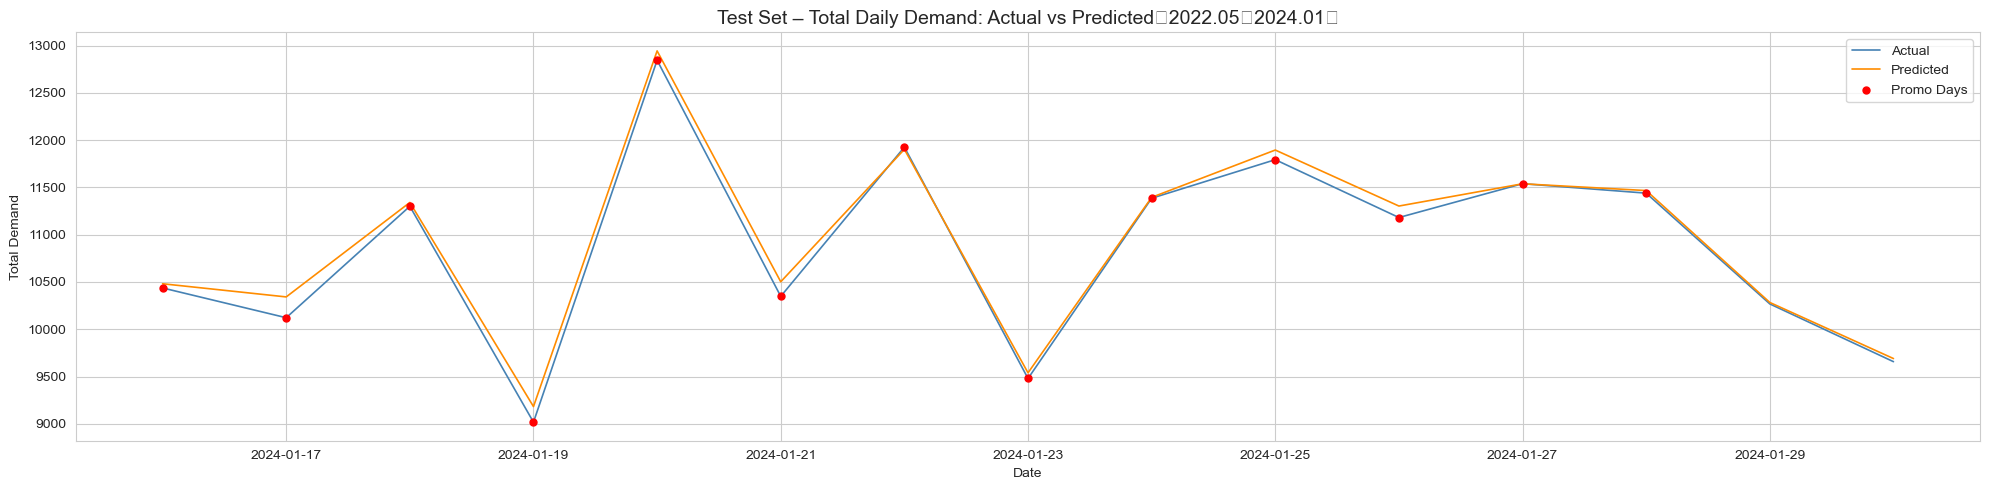

In [164]:
# 准备测试集的每日汇总
test_results = test[['Date', 'Promotion']].copy()
test_results['Actual'] = y_test.values
test_results['Predicted'] = y_pred_test
daily_test = test_results.groupby('Date').agg({'Actual': 'sum', 'Predicted': 'sum'}).reset_index()

# 绘图（加宽以便看清长期趋势）
fig, ax = plt.subplots(figsize=(20, 5))
ax.plot(daily_test['Date'], daily_test['Actual'], label='Actual', color='steelblue', linewidth=1.2)
ax.plot(daily_test['Date'], daily_test['Predicted'], label='Predicted', color='darkorange', linewidth=1.2)

# 高亮促销日
promo_days = daily_test[daily_test['Date'].isin(test[test['Promotion'] == 1]['Date'])]
ax.scatter(promo_days['Date'], promo_days['Actual'], color='red', s=25, zorder=5, label='Promo Days')

ax.set_title('Test Set – Total Daily Demand: Actual vs Predicted（2022.05～2024.01）', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Total Demand')
ax.legend()
plt.tight_layout()
plt.show()

Top 20 features by importance:


,Feature Id,Importances
0,Price,30.534438
1,Category,20.032334
2,Epidemic,12.441779
3,Promotion,6.932694
4,Product ID,6.710025
5,Competitor Pricing,6.687356
6,Discount,5.399710
7,Store ID,4.329447
8,Weather Condition,2.702744
9,Region,1.939726


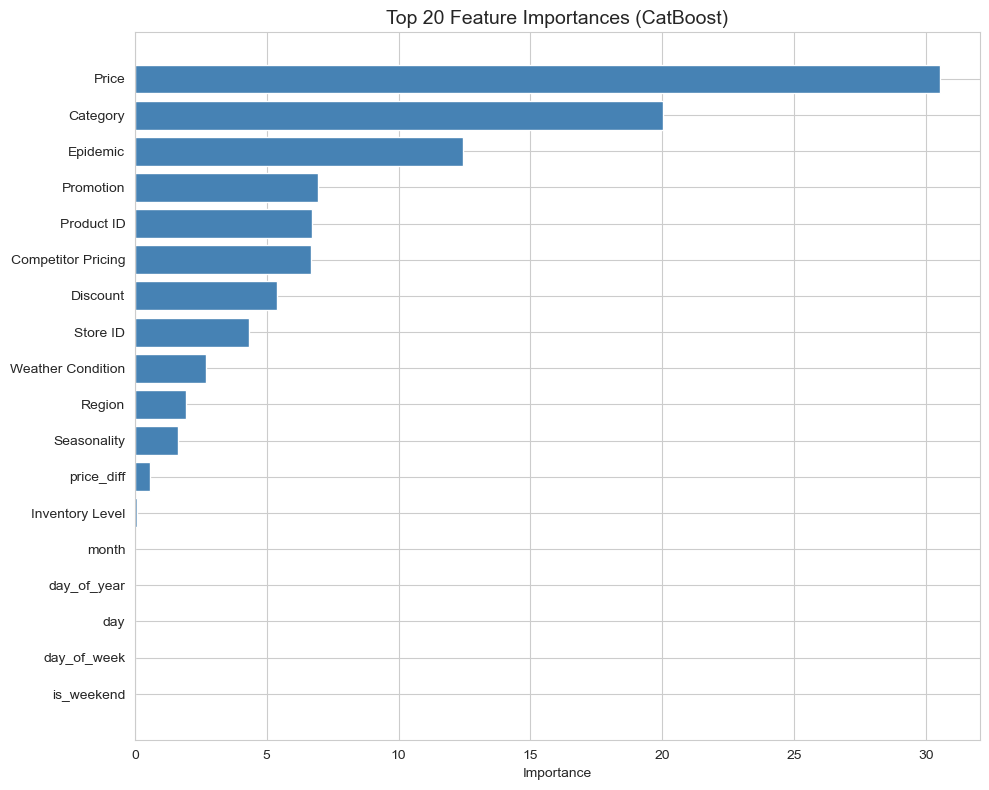

In [165]:
# ---------------------------------------------------------
# ## 10. Feature Importance
# ---------------------------------------------------------

# CatBoost native feature importance
fi = model.get_feature_importance(prettified=True)
print("Top 20 features by importance:")
display(fi.head(20))

plt.figure(figsize=(10, 8))
plt.barh(fi['Feature Id'].head(20)[::-1], fi['Importances'].head(20)[::-1], color='steelblue')
plt.title('Top 20 Feature Importances (CatBoost)', fontsize=14)
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

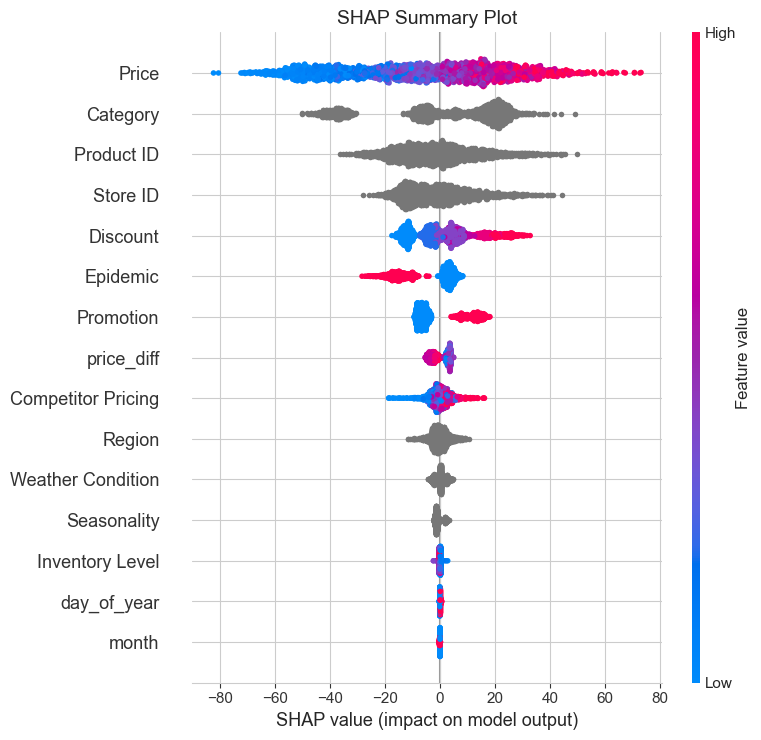

In [166]:
# ---------------------------------------------------------
# ## 11. SHAP Analysis (Interpretability)
# ---------------------------------------------------------

# Use a sample for SHAP (it can be slow on full data)
shap_sample = X_val.sample(n=min(2000, len(X_val)), random_state=42)

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(shap_sample)

# Summary plot
shap.summary_plot(shap_values, shap_sample, max_display=15, show=False)
plt.title('SHAP Summary Plot', fontsize=14)
plt.tight_layout()
plt.show()

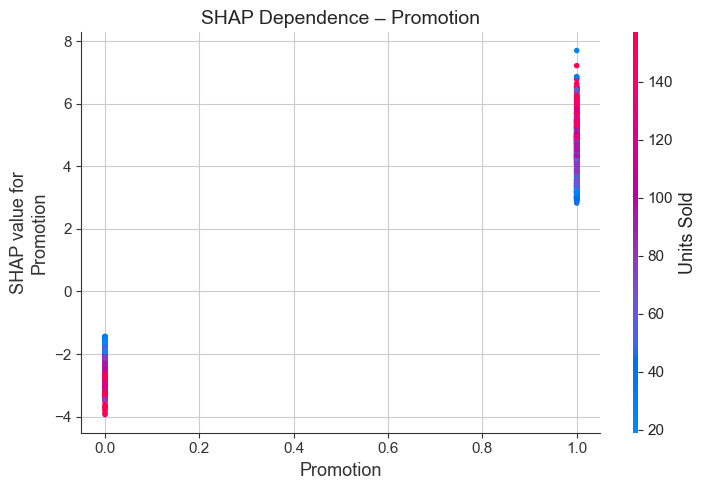

In [106]:
# SHAP dependence plot for Promotion feature
promo_idx = all_features.index('Promotion')
if promo_idx < shap_values.shape[1]:
    shap.dependence_plot(promo_idx, shap_values, shap_sample, 
                         feature_names=all_features, show=False)
    plt.title('SHAP Dependence – Promotion', fontsize=14)
    plt.tight_layout()
    plt.show()

In [107]:
# ---------------------------------------------------------
# ## 12. Save the Model
# ---------------------------------------------------------

model.save_model('demand_forecaster.cbm')
print("Model saved as 'demand_forecaster.cbm'")

Model saved as 'demand_forecaster.cbm'


In [108]:
# ---------------------------------------------------------
# ## 13. Summary & Next Steps
# ---------------------------------------------------------

summary = f"""
================================================================================
                     DEMAND FORECASTING PROJECT – SUMMARY
================================================================================

1. DATA OVERVIEW
   - Total records: {len(df):,}
   - Date range: {df['Date'].min().date()} → {df['Date'].max().date()}
   - Stores: {df['Store ID'].nunique()}   |  Products: {df['Product ID'].nunique()}
   - Categories: {df['Category'].nunique()}  |  Regions: {df['Region'].nunique()}

2. MODEL PERFORMANCE
   - Validation MAE : {mean_absolute_error(y_val, y_pred_val):.2f}
   - Validation MAPE: {mean_absolute_percentage_error(y_val, y_pred_val)*100:.1f}%
   - Test MAE       : {mean_absolute_error(y_test, y_pred_test):.2f}
   - Test MAPE      : {mean_absolute_percentage_error(y_test, y_pred_test)*100:.1f}%

3. PROMOTION ANALYSIS
   - Average uplift from promotions: {lift:.1f}%
   - Model performs well on promo days (see dedicated metrics above).

4. TOP FEATURES
   (Printed in Section 10)

5. MODEL ARTIFACT
   - Saved as 'demand_forecaster.cbm'

================================================================================
"""
print(summary)


                     DEMAND FORECASTING PROJECT – SUMMARY

1. DATA OVERVIEW
   - Total records: 76,000
   - Date range: 2022-01-01 → 2024-01-30
   - Stores: 5   |  Products: 20
   - Categories: 5  |  Regions: 4

2. MODEL PERFORMANCE
   - Validation MAE : 9.00
   - Validation MAPE: 11.7%
   - Test MAE       : 10.02
   - Test MAPE      : 10.2%

3. PROMOTION ANALYSIS
   - Average uplift from promotions: 29.7%
   - Model performs well on promo days (see dedicated metrics above).

4. TOP FEATURES
   (Printed in Section 10)

5. MODEL ARTIFACT
   - Saved as 'demand_forecaster.cbm'




In [109]:
# ---------------------------------------------------------
# ## 14. Going Further – Productionisation Ideas
# ---------------------------------------------------------
# 
# To turn this into a production‑ready system (matching your resume bullet):
# 
# 1. Package the feature engineering in a reusable pipeline (e.g., a Scikit‑learn Pipeline 
#    with custom transformers).
# 2. Build a REST API with FastAPI that accepts a date, store, product, and promo flag,
#    computes the necessary lag features from a recent‑history lookup table, and returns
#    the predicted demand.
# 3. Containerise the API with Docker.
# 4. Set up a retraining schedule (e.g., weekly cron job / Airflow DAG) that reads the latest
#    data, retrains the model, and updates the saved .cbm file.
# 5. Add monitoring – track prediction error over time and set up alerts if drift detected.
#

print("Notebook complete. Model is ready for deployment! 🚀")

Notebook complete. Model is ready for deployment! 🚀
